# RQ2 — Feature Importance Analysis

**Research question:** Which pre-release features contribute most to predicting movie profitability?

This notebook trains the best classifier from RQ1 and extracts feature importance scores to identify which signals drive hit prediction. Features are categorized into Financial, Engagement, Production, Content, Timing, Language, and Genre groups.

## 1. Setup and imports

In [1]:
# Imports
import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, precision_recall_curve, roc_curve,
)

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not available, skipping XGBoost model")

# Plot styling
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "legend.frameon": False,
})

COLORS = {
    "primary":   "#185FA5",
    "accent":    "#D85A30",
    "secondary": "#1D9E75",
    "gray":      "#888780",
    "amber":     "#BA7517",
    "purple":    "#7F77DD",
    "pink":      "#D4537E",
}

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Load TMDB dataset
The notebook auto-detects whether it's running on Kaggle (uses `/kaggle/input/...`) or locally.

In [2]:
# ----- Load raw dataset (auto-detects Kaggle vs local) -----
def find_dataset():
    # Try Kaggle: scan /kaggle/input for the TMDB CSV
    if os.path.exists("/kaggle/input"):
        for csv in glob.glob("/kaggle/input/**/*.csv", recursive=True):
            if "tmdb" in csv.lower() or "movies" in csv.lower():
                return csv
    # Fallback: local file
    for candidate in ["TMDB_all_movies.csv", "../TMDB_all_movies.csv"]:
        if os.path.exists(candidate):
            return candidate
    raise FileNotFoundError("Could not find TMDB CSV. On Kaggle, attach 'TMDB Movies Daily Updates' dataset. Locally, place TMDB_all_movies.csv in this folder.")

DATA_PATH = find_dataset()
print(f"Loading dataset from: {DATA_PATH}")
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Raw dataset shape: {df_raw.shape}")


Loading dataset from: TMDB_all_movies.csv


Raw dataset shape: (1188481, 28)


## 3. Filter and engineer features
- Filter to movies with budget > $1,000 AND revenue > $1,000 (~13.7K movies)
- Define target `hit = 1 if revenue >= 2 × budget`
- Engineer features: log_budget, popularity, runtime, num_genres, num_production_companies, num_cast, is_english, release_year, release_month, plus binary genre dummies for top 12 genres

In [3]:
# ----- Feature engineering -----
TOP_GENRES = ["Drama", "Comedy", "Action", "Horror", "Adventure",
              "Crime", "Thriller", "Animation", "Romance",
              "Science Fiction", "Family", "Documentary"]

def build_modeling_df(df):
    m = df[(df["budget"] > 1000) & (df["revenue"] > 1000)].copy()
    m["hit"] = (m["revenue"] >= 2 * m["budget"]).astype(int)
    m["release_date"] = pd.to_datetime(m["release_date"], errors="coerce")
    m["release_year"] = m["release_date"].dt.year
    m["release_month"] = m["release_date"].dt.month
    m["log_budget"] = np.log1p(m["budget"])
    m["log_popularity"] = np.log1p(m["popularity"].fillna(0))
    m["num_genres"] = m["genres"].fillna("").apply(lambda s: len([g for g in s.split(",") if g.strip()]))
    m["num_production_companies"] = m["production_companies"].fillna("").apply(
        lambda s: len([c for c in s.split(",") if c.strip()]))
    m["num_cast"] = m["cast"].fillna("").apply(lambda s: len([c for c in s.split(",") if c.strip()]))
    m["is_english"] = (m["original_language"] == "en").astype(int)
    m["primary_genre"] = m["genres"].fillna("").apply(
        lambda s: s.split(",")[0].strip() if s else "Unknown")
    for g in TOP_GENRES:
        m[f"genre_{g.lower().replace(' ', '_')}"] = m["genres"].fillna("").str.contains(g).astype(int)
    m = m.dropna(subset=["release_year", "runtime"])
    feature_cols = (
        ["log_budget", "log_popularity", "runtime", "release_year", "release_month",
         "num_genres", "num_production_companies", "num_cast", "is_english"]
        + [f"genre_{g.lower().replace(' ', '_')}" for g in TOP_GENRES]
    )
    return m, feature_cols

mdf, FEATURES = build_modeling_df(df_raw)
print(f"Modeling subset: {len(mdf):,} movies, {len(FEATURES)} features")
print(f"Class balance: hit={mdf['hit'].mean():.3f}")


Modeling subset: 13,431 movies, 21 features
Class balance: hit=0.435


## 4. Analysis for RQ2


In [4]:
# ===== RQ2: Feature Importance =====
X = mdf[FEATURES].fillna(0).values
y = mdf["hit"].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

if HAS_XGB:
    mdl = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                        random_state=RANDOM_STATE, eval_metric="logloss",
                        use_label_encoder=False, n_jobs=-1)
else:
    mdl = GradientBoostingClassifier(random_state=RANDOM_STATE)

mdl.fit(X_train, y_train)

# Feature importance
importances = mdl.feature_importances_
fi = (pd.DataFrame({"feature": FEATURES, "importance": importances})
        .sort_values("importance", ascending=False)
        .head(10)
        .reset_index(drop=True))

# Categorize
def cat(f):
    if "budget" in f: return "Financial"
    if "popularity" in f: return "Engagement"
    if "production" in f: return "Production"
    if "runtime" in f or "num_genres" in f or "num_cast" in f: return "Content"
    if "year" in f or "month" in f: return "Timing"
    if "english" in f: return "Language"
    if "genre_" in f: return "Genre"
    return "Other"
fi["category"] = fi["feature"].apply(cat)
fi.to_csv("table_rq2_feature_importance.csv", index=False)
print("Saved table_rq2_feature_importance.csv")
fi


Saved table_rq2_feature_importance.csv


,feature,importance,category
0,log_popularity,0.089944,Engagement
1,log_budget,0.063330,Financial
2,genre_comedy,0.060405,Genre
3,genre_drama,0.059090,Genre
4,is_english,0.055269,Language
5,genre_horror,0.054162,Genre
6,release_year,0.052702,Timing
7,genre_science_fiction,0.052251,Genre
8,runtime,0.047973,Content
9,genre_thriller,0.047518,Genre


## 5. Generate publication figure

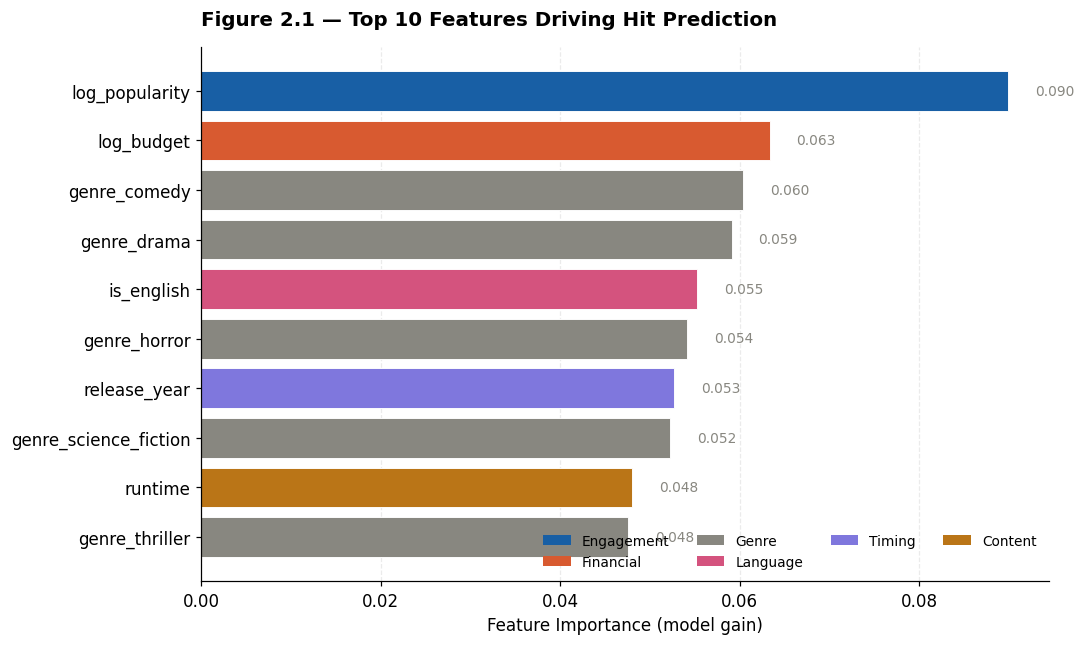

Saved fig_rq2_feature_importance.pdf / .png


In [5]:
# ===== Figure 2.1 — Feature importance bar chart =====
fig, ax = plt.subplots(figsize=(10, 6))
cat_colors = {"Financial": COLORS["accent"], "Engagement": COLORS["primary"],
              "Production": COLORS["secondary"], "Content": COLORS["amber"],
              "Timing": COLORS["purple"], "Language": COLORS["pink"], "Genre": COLORS["gray"], "Other": "#444444"}
bar_colors = [cat_colors.get(c, "#444444") for c in fi["category"]]

y_pos = np.arange(len(fi))
ax.barh(y_pos, fi["importance"], color=bar_colors, edgecolor="white", linewidth=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(fi["feature"])
ax.invert_yaxis()
ax.set_xlabel("Feature Importance (model gain)")
ax.set_title("Figure 2.1 — Top 10 Features Driving Hit Prediction", loc="left", pad=14)

from matplotlib.patches import Patch
used_cats = fi["category"].unique()
legend_elements = [Patch(facecolor=cat_colors[c], label=c) for c in used_cats]
ax.legend(handles=legend_elements, ncol=min(4, len(used_cats)), loc="lower right", fontsize=9)

for i, v in enumerate(fi["importance"]):
    ax.text(v + 0.003, i, f"{v:.3f}", va="center", fontsize=9, color=COLORS["gray"])
ax.grid(axis="x", alpha=0.25, linestyle="--")
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("fig_rq2_feature_importance.pdf")
plt.savefig("fig_rq2_feature_importance.png")
plt.show()
print("Saved fig_rq2_feature_importance.pdf / .png")


## 6. Conclusion

Financial signals (budget) and engagement signals (popularity) dominate, while individual genre indicators contribute only marginally. This validates the intuition that scale and audience interest matter more than genre alone.